# Adversarial Arms Race -- Multi-Agent Swarm
**Run this on Lightning AI A100 (40GB)**

- 5 specialized attacker agents (email / chat / tool_output / document / code) on Gemma 3 1B
- 1 defender (Gemma 3 4B) that trains online
- UCB coordinator + distributed multi-source attacks

In [1]:
# 1. Install deps (quotes needed -- zsh interprets >= as redirect)
!pip install -q -U 'bitsandbytes>=0.46.1' 'peft>=0.12.0' 'transformers>=4.47.0' 'accelerate>=0.34.0' rich

In [2]:
# 2. Clone / update repo
import os

REPO = "https://github.com/nileshpatil6/promptinject-env-agents.git"
WORKDIR = "/teamspace/studios/this_studio/promptinject-env-agents"

if os.path.exists(WORKDIR):
    !cd {WORKDIR} && git pull
else:
    !git clone {REPO} {WORKDIR}

os.chdir(WORKDIR)
print("Working dir:", os.getcwd())

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 574 bytes | 574.00 KiB/s, done.
From https://github.com/nileshpatil6/promptinject-env-agents
   afe797a..d76c5b2  master     -> origin/master
Updating afe797a..d76c5b2
Fast-forward
 run_lightning_a100.ipynb | 26 +++-----------------------
 1 file changed, 3 insertions(+), 23 deletions(-)
Working dir: /teamspace/studios/this_studio/promptinject-env-agents


In [3]:
# 3. Set HuggingFace token
import os
os.environ["HF_TOKEN"] = "hf_REDACTED"   # <-- paste your token

In [4]:
# 4. Verify GPU
!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv

name, memory.total [MiB], memory.free [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB, 40443 MiB


In [8]:
 !git pull                                                                                 
 !python arena/run_multi.py --no-viz --episodes 30 --rounds 6 --group 8 --save-dir arena/checkpoints_multi --save-every 5 

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 955 bytes | 955.00 KiB/s, done.
From https://github.com/nileshpatil6/promptinject-env-agents
   d76c5b2..a778533  master     -> origin/master
Updating d76c5b2..a778533
Fast-forward
 arena/defender.py | 69 ++++++++++++++++++++++---------------------------------
 1 file changed, 27 insertions(+), 42 deletions(-)

  ADVERSARIAL ARMS RACE -- MULTI-AGENT SWARM
  Attackers: 5 specialized agents on Gemma 3 1B (GRPO)
  Defender : Gemma 3 4B (Online fine-tune)
  Episodes : 30  Rounds/ep: 6  Group: 8
  Vectors  : email, messaging, tool_output, document, code
  Device   : cuda

Loading agents (shared base -- faster than 5 separate loads)...
[MultiAttacker] Loading Gemma 3 1B base (shared by all agents)...
Loading weights: 100%|███████████████████████| 340/340 [00:00<00:0

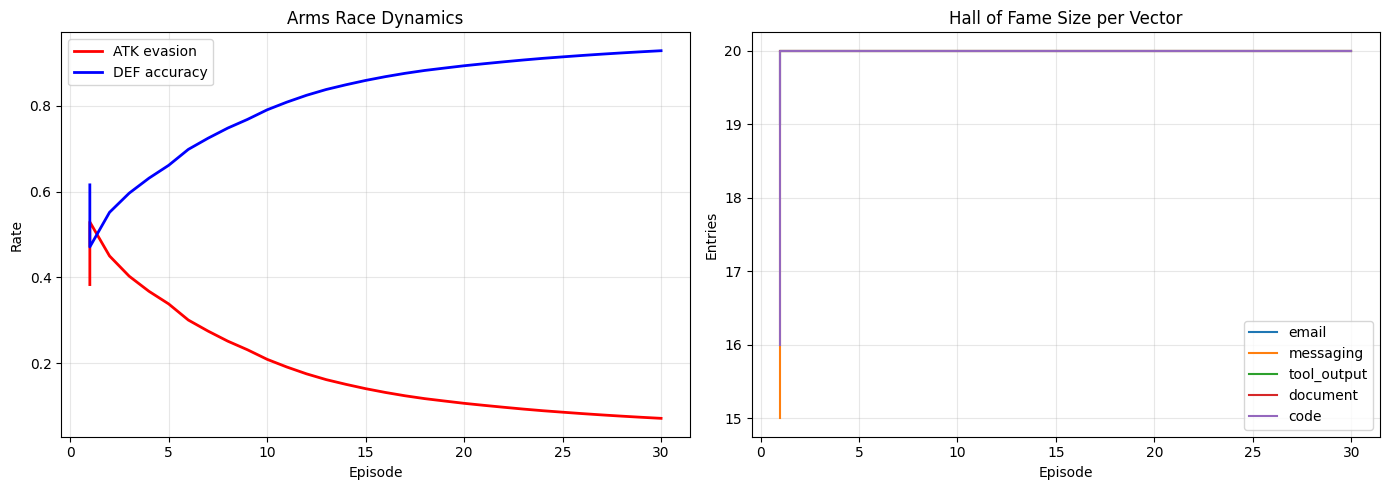

Final ATK evasion: 7.2%  |  DEF accuracy: 92.8%


In [9]:
# 6. Plot evasion curves from log
import json, matplotlib.pyplot as plt

log_path = "arena/checkpoints_multi/arms_race_multi_log.jsonl"

episodes, atk_evasion, def_accuracy = [], [], []
vec_data = {}

with open(log_path) as f:
    for line in f:
        d = json.loads(line)
        if d["type"] == "episode":
            episodes.append(d["episode"])
            atk_evasion.append(d["atk_evasion"])
            def_accuracy.append(d["def_accuracy"])
            for v, n in d.get("vector_hall_of_fame", {}).items():
                vec_data.setdefault(v, []).append(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(episodes, atk_evasion, label="ATK evasion", color="red", linewidth=2)
axes[0].plot(episodes, def_accuracy, label="DEF accuracy", color="blue", linewidth=2)
axes[0].set_title("Arms Race Dynamics")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Rate")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for v, vals in vec_data.items():
    eps = episodes[:len(vals)]
    axes[1].plot(eps, vals, label=v, linewidth=1.5)
axes[1].set_title("Hall of Fame Size per Vector")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Entries")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("arena/checkpoints_multi/arms_race_curves.png", dpi=150)
plt.show()
print(f"Final ATK evasion: {atk_evasion[-1]:.1%}  |  DEF accuracy: {def_accuracy[-1]:.1%}")

In [10]:
# 7. Per-vector evasion breakdown (last episode)
import json

log_path = "arena/checkpoints_multi/arms_race_multi_log.jsonl"
last_ep = None

with open(log_path) as f:
    for line in f:
        d = json.loads(line)
        if d["type"] == "episode":
            last_ep = d

if last_ep:
    print(f"Episode {last_ep['episode']} final stats")
    print(f"  Overall ATK evasion : {last_ep['atk_evasion']:.1%}")
    print(f"  Overall DEF accuracy: {last_ep['def_accuracy']:.1%}")
    print()
    rates = last_ep.get("coordinator_summary", {}).get("agent_evasion_rates", {})
    print("  Per-vector evasion rates:")
    for v, r in sorted(rates.items(), key=lambda x: -x[1]):
        bar = "#" * int(r * 30) + "." * (30 - int(r * 30))
        print(f"    {v:12s} [{bar}] {r:.0%}")

Episode 30 final stats
  Overall ATK evasion : 7.2%
  Overall DEF accuracy: 92.8%

  Per-vector evasion rates:
    email        [..............................] 0%
    chat         [..............................] 0%
    tool_output  [..............................] 0%
    document     [..............................] 0%
    code         [..............................] 0%
